# Seismic Acquisition Model —  (Template, 1 Spread, Full Line)
Notebook ini adalah versi **template/kosongan**: struktur kode sama seperti versi lengkap (**1 geometri akuisisi tunggal yang langsung mencakup seluruh panjang lintasan, tanpa roll-along bertahap**), tetapi **nilai asumsi parameter** (kecepatan layer, parameter mesh, noise, parameter inversi) dan **konfigurasi shot & geophone** (spasi, posisi awal/akhir, klasifikasi tipe shot) dikosongkan (`None`).

Isi setiap bagian yang ditandai `# TODO` sesuai asumsi/skenario akuisisi Anda sebelum menjalankan notebook ini.

In [1]:
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import pygimli.physics.traveltime as tt
import matplotlib.pyplot as plt
from collections import Counter


## 0. Parameter Asumsi & Konfigurasi Akuisisi
Isi seluruh nilai `None` di bawah ini sesuai asumsi Anda. Nilai ini akan dipakai di seluruh bagian notebook.

In [2]:
# ============================================================
# A. ASUMSI PARAMETER KECEPATAN (Vp) PER LAYER  [m/s]
# ============================================================
VP_LAYER1 = 375   # TODO: kecepatan Vp Layer 1 (paling atas)
VP_LAYER2 = 500   # TODO: kecepatan Vp Layer 2 (tengah)
VP_LAYER3 = 1200   # TODO: kecepatan Vp Layer 3 (paling bawah)

# ============================================================
# B. PARAMETER MESH
# ============================================================
MESH_QUALITY = 34.3   # TODO: kualitas elemen mesh, contoh referensi: 34.3
MESH_AREA    = 3   # TODO: luas maksimum elemen mesh, contoh referensi: 3
MESH_SMOOTH  = [1, 10]   # TODO: parameter smoothing, contoh referensi: [1, 10]

# ============================================================
# C. KONFIGURASI GEOPHONE (RECEIVER) — 1 SPREAD, MENCAKUP SELURUH LINE
#    (tidak ada roll-along bertahap, semua geophone aktif sekaligus)
# ============================================================
RECV_X_START = 1.5   # TODO: posisi X geophone pertama (m), contoh referensi -> 1.5
RECV_X_END   = 166.5   # TODO: posisi X geophone terakhir (m), contoh referensi -> 166.5
RECV_SPACING = 3   # TODO: spasi antar geophone (m), contoh referensi -> 3

# ============================================================
# D. KONFIGURASI SHOT — 1 SPREAD, MENCAKUP SELURUH LINE
# ============================================================
SHOT_X_START = 0.0   # TODO: posisi X shot pertama (m), contoh referensi -> 0.0
SHOT_X_END   = 168.0   # TODO: posisi X shot terakhir (m), contoh referensi -> 168.0
SHOT_SPACING = 3   # TODO: spasi antar shot (m), contoh referensi -> 3

# ============================================================
# E. KLASIFIKASI TIPE SHOT (berdasarkan nomor urut SH, 1-indexed)
#    Isi sebagai range nomor SH, contoh: range(1, 7)
# ============================================================
SHOT_TYPE_RANGES = {
    'P.Near': range(1,7),   # TODO: contoh referensi -> range(1, 7)
    'Near':   range(7,17),   # TODO: contoh referensi -> range(7, 17)
    'Mid':    range(17,42),   # TODO: contoh referensi -> range(17, 42)
    'Far':    range(42,52),   # TODO: contoh referensi -> range(42, 52)
    'P.Far':  range(52,58),   # TODO: contoh referensi -> range(52, 58)
}

# ============================================================
# F. PARAMETER NOISE SIMULASI
# ============================================================
NOISE_LEVEL = 0.001   # TODO: contoh referensi -> 0.001
NOISE_ABS   = 0.001   # TODO: contoh referensi -> 0.001
SEED        = 1337   # TODO: contoh referensi -> 1337

# ============================================================
# G. PARAMETER INVERSI
# ============================================================
SEC_NODES          = 2   # TODO: contoh referensi -> 2
PARA_MAX_CELL_SIZE = 15.0   # TODO: contoh referensi -> 15.0
MAX_ITER           = 20   # TODO: contoh referensi -> 10


## 1. Model Geologi (3 Layer)
Data horizon atas (`top_data`) merupakan data model awal (given) — bukan asumsi parameter akuisisi, sehingga tetap dipakai apa adanya. Layer 2 dan Layer 3 dibagi otomatis (proporsi sama rata dari BASE).

Interior marker points:
  Layer 1 : (84.9, 821.67)
  Layer 2 : (84.9, 815.40)
  Layer 3 : (84.9, 809.13)


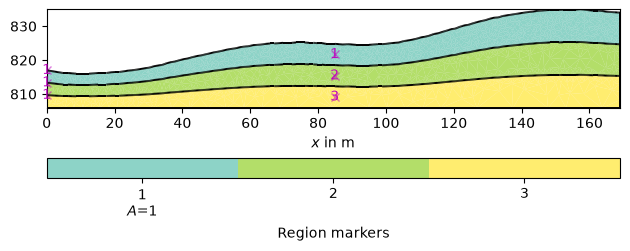

In [3]:
"""
Seismic Acquisition Model - PyGIMLi
3-layer model with full curved top horizon from initial model data.
"""

# -- Raw horizon data (X, Y_top) — data model awal (given) --------------------
top_data = np.array([
    [0.0,817],[1.2,816.8],[2.4,816.6],[3.7,816.4],[4.9,816.2],
    [6.2,816.2],[7.5,816.1],[8.7,816.0],[10.0,816.0],[11.3,816.0],
    [12.5,816.0],[13.8,816.1],[15.1,816.2],[16.3,816.2],[17.6,816.2],
    [18.9,816.4],[20.1,816.5],[21.4,816.5],[22.7,816.7],[24.0,816.9],
    [25.2,817.0],[26.5,817.2],[27.8,817.4],[29.0,817.6],[30.3,817.8],
    [31.6,818.2],[32.8,818.4],[34.1,818.6],[35.4,819.1],[36.7,819.4],
    [37.9,819.6],[39.2,820.0],[40.5,820.3],[41.7,820.5],[43.0,820.9],
    [44.3,821.2],[45.6,821.4],[46.8,821.7],[48.1,822.0],[49.4,822.3],
    [50.6,822.5],[51.9,822.8],[53.2,823.1],[54.4,823.3],[55.7,823.5],
    [57.0,823.8],[58.3,824.0],[59.5,824.1],[60.8,824.4],[62.1,824.5],
    [63.3,824.6],[64.6,824.8],[65.9,824.9],[67.1,824.9],[68.4,825.0],
    [69.7,825.1],[71.0,825.1],[72.2,825.1],[73.5,825.2],[74.8,825.2],
    [76.0,825.2],[77.3,825.1],[78.6,825.1],[79.8,825.0],[81.1,825.0],
    [82.4,824.8],[83.6,824.8],[84.9,824.8],[86.2,824.7],[87.4,824.6],
    [88.7,824.7],[90.0,824.6],[91.2,824.5],[92.5,824.5],[93.8,824.5],
    [95.0,824.5],[96.3,824.6],[97.6,824.7],[98.9,824.7],[100.1,824.8],
    [101.4,825.0],[102.7,825.1],[103.9,825.2],[105.2,825.6],[106.5,825.8],
    [107.7,826.0],[109.0,826.3],[110.3,826.7],[111.6,826.9],[112.8,827.2],
    [114.1,827.7],[115.4,827.9],[116.6,828.3],[117.9,828.7],[119.2,829.1],
    [120.5,829.3],[121.7,829.8],[123.0,830.2],[124.3,830.4],[125.5,830.8],
    [126.8,831.2],[128.1,831.5],[129.4,831.8],[130.6,832.2],[131.9,832.5],
    [133.2,832.6],[134.4,833.0],[135.7,833.2],[137.0,833.4],[138.2,833.6],
    [139.5,833.8],[140.8,834.0],[142.1,834.2],[143.3,834.3],[144.6,834.5],
    [145.9,834.6],[147.1,834.7],[148.4,834.8],[149.7,834.8],[150.9,834.8],
    [152.2,834.9],[153.5,834.9],[154.7,834.9],[156.0,834.9],[157.3,835.0],
    [158.5,834.9],[159.8,834.7],[161.1,834.6],[162.4,834.6],[163.6,834.5],
    [164.9,834.3],[166.2,834.2],[167.4,834.1],[169.0,834.0],
])

xs    = top_data[:, 0]
y_top = top_data[:, 1]
BASE  = 806.0

# -- Derived horizons (equal-thirds split from base) -------------------------
y_h23 = BASE + (2.0 / 3.0) * (y_top - BASE)   # boundary Layer 1 / Layer 2
y_h12 = BASE + (1.0 / 3.0) * (y_top - BASE)   # boundary Layer 2 / Layer 3

# -- Build polygons -------------------------------------------------------------
pts1 = [[x,y] for x,y in zip(xs, y_top)] + [[x,y] for x,y in zip(xs[::-1], y_h23[::-1])]
pts2 = [[x,y] for x,y in zip(xs, y_h23)] + [[x,y] for x,y in zip(xs[::-1], y_h12[::-1])]
pts3 = [[x,y] for x,y in zip(xs, y_h12)] + [[xs[-1], BASE], [xs[0], BASE]]

layer1 = mt.createPolygon(pts1, isClosed=True, addNodes=3)
layer2 = mt.createPolygon(pts2, isClosed=True, addNodes=3)
layer3 = mt.createPolygon(pts3, isClosed=True, addNodes=3)

geom = layer1 + layer2 + layer3

# -- Assign region markers via interior points ---------------------------------
mid_idx = len(xs) // 2
x_mid   = xs[mid_idx]

y1_int = (y_top[mid_idx] + y_h23[mid_idx]) / 2   # inside Layer 1
y2_int = (y_h23[mid_idx] + y_h12[mid_idx]) / 2   # inside Layer 2
y3_int = (y_h12[mid_idx] + BASE)           / 2   # inside Layer 3

geom.addRegionMarker([x_mid, y1_int], marker=1, area=1)
geom.addRegionMarker([x_mid, y2_int], marker=2)
geom.addRegionMarker([x_mid, y3_int], marker=3)

print("Interior marker points:")
print(f"  Layer 1 : ({x_mid:.1f}, {y1_int:.2f})")
print(f"  Layer 2 : ({x_mid:.1f}, {y2_int:.2f})")
print(f"  Layer 3 : ({x_mid:.1f}, {y3_int:.2f})")

fig, ax = pg.show(geom)


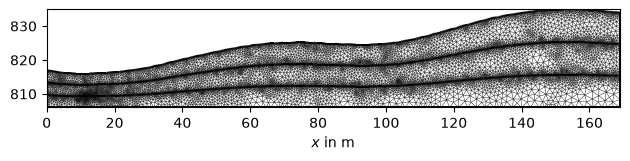


Mesh summary:
  Nodes : 11674
  Cells : 22639
  Marker counts: {k: counts[k] for k in sorted(counts)}

Horizon ranges:
  y_top : 816.0 - 835.0 m
  y_h23 : 812.7 - 825.3 m
  y_h12 : 809.3 - 815.7 m
  BASE  : 806.0 m (flat)


In [4]:
# -- Create mesh (memakai parameter mesh dari bagian 0.B) ----------------------
mesh = mt.createMesh(geom, quality=MESH_QUALITY, area=MESH_AREA, smooth=MESH_SMOOTH)

fig2, ax2 = pg.show(mesh)
pg.wait()

# -- Summary ---------------------------------------------------------------------
import collections
markers = [mesh.cell(i).marker() for i in range(mesh.cellCount())]
counts  = collections.Counter(markers)
print("\nMesh summary:")
print(f"  Nodes : {mesh.nodeCount()}")
print(f"  Cells : {mesh.cellCount()}")
print(f"  Marker counts: {{k: counts[k] for k in sorted(counts)}}")
print("\nHorizon ranges:")
print(f"  y_top : {y_top.min():.1f} - {y_top.max():.1f} m")
print(f"  y_h23 : {y_h23.min():.1f} - {y_h23.max():.1f} m")
print(f"  y_h12 : {y_h12.min():.1f} - {y_h12.max():.1f} m")
print(f"  BASE  : {BASE:.1f} m (flat)")


## 2. Skema Akuisisi Seismik — 1 Spread, Mencakup Seluruh Line
Posisi geophone dan shot dibangun dari parameter konfigurasi di bagian 0.C dan 0.D, langsung mencakup seluruh panjang lintasan dalam satu geometri (tanpa roll-along bertahap). Pastikan nilai tersebut sudah diisi sebelum menjalankan sel ini.

In [5]:
def surface_y(x):
    """Interpolate Y on top horizon at position x."""
    return float(np.interp(x, top_data[:, 0], top_data[:, 1]))

# -- Acquisition positions (1 spread / 1 roll-along) ---------------------------
recv1 = np.arange(RECV_X_START, RECV_X_END + 0.01, RECV_SPACING)
shot1 = np.arange(SHOT_X_START, SHOT_X_END + 0.01, SHOT_SPACING)

# -- Shot type lookup (1-indexed SH number), dibangun dari SHOT_TYPE_RANGES ----
SHOT_TYPE = {}
for stype, rng in SHOT_TYPE_RANGES.items():
    for sh_num in rng:
        SHOT_TYPE[sh_num] = stype

# -- Build unique sensor positions ---------------------------------------------
all_x    = np.unique(np.concatenate([recv1, shot1]))
sensors  = np.array([[x, surface_y(x)] for x in all_x])  # (N, 2)
x_to_idx = {round(x, 4): i for i, x in enumerate(all_x)}

def idx(x):
    return x_to_idx[round(x, 4)]

# -- Build trace list -----------------------------------------------------------
s_list, g_list, type_list = [], [], []

for sh_num, sx in enumerate(shot1, start=1):
    for rx in recv1:
        s_list.append(idx(sx))
        g_list.append(idx(rx))
        type_list.append(SHOT_TYPE[sh_num])

s_arr = pg.Vector(np.array(s_list, dtype=float))
g_arr = pg.Vector(np.array(g_list, dtype=float))

# -- Assemble PyGIMLi DataContainer --------------------------------------------
scheme = pg.DataContainer()

for x, y in sensors:
    scheme.createSensor(pg.Pos(x, y))

scheme.resize(len(s_list))
scheme.registerSensorIndex('s')
scheme.registerSensorIndex('g')
scheme.set('s', s_arr)
scheme.set('g', g_arr)
scheme.markValid(scheme('g') != scheme('s'))

# -- Print summary ----------------------------------------------------------------
print(f"Sensors (unique) : {scheme.sensorCount()}")
print(f"Traces (total)   : {scheme.size()}")
print(f"Sensor X range   : {sensors[:,0].min():.1f} - {sensors[:,0].max():.1f} m")
print(f"Sensor Y range   : {sensors[:,1].min():.2f} - {sensors[:,1].max():.2f} m")

print("\nTraces per shot type:")
for k, v in sorted(Counter(type_list).items()):
    print(f"  {k:7s} : {v} traces")


Sensors (unique) : 113
Traces (total)   : 3192
Sensor X range   : 0.0 - 168.0 m
Sensor Y range   : 816.00 - 834.98 m

Traces per shot type:
  Far     : 560 traces
  Mid     : 1400 traces
  Near    : 560 traces
  P.Far   : 336 traces
  P.Near  : 336 traces


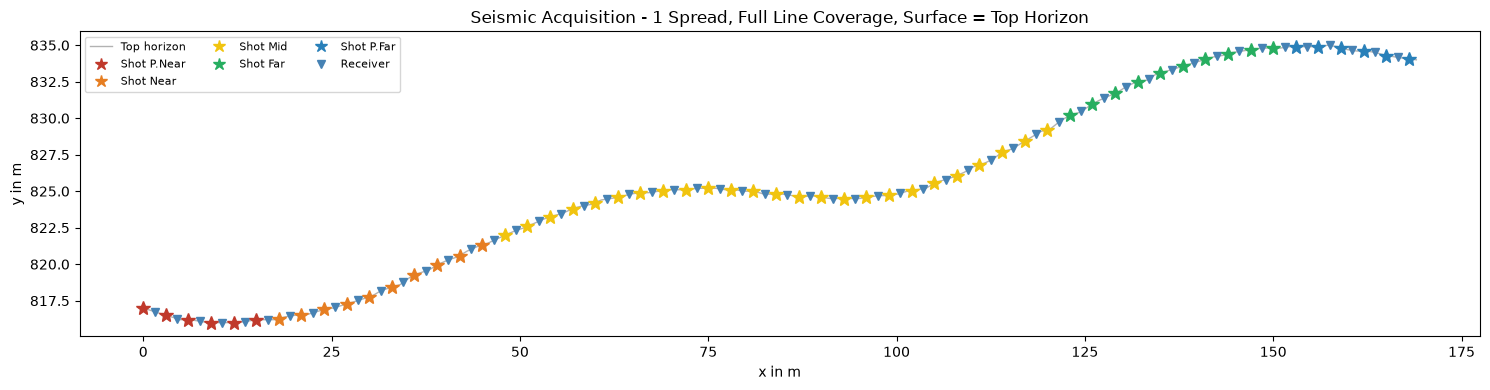


Plot saved -> acquisition_scheme.png


In [6]:
# -- Visualise acquisition scheme ---------------------------------------------
type_colors = {
    'P.Near': '#c0392b',
    'Near':   '#e67e22',
    'Mid':    '#f1c40f',
    'Far':    '#27ae60',
    'P.Far':  '#2980b9',
}

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(top_data[:, 0], top_data[:, 1], 'k-', lw=1, alpha=0.3, label='Top horizon')

for rx in recv1:
    ax.plot(rx, surface_y(rx), 'v', color='steelblue', ms=6, zorder=3)

for sh_num, sx in enumerate(shot1, 1):
    ax.plot(sx, surface_y(sx), '*', color=type_colors[SHOT_TYPE[sh_num]], ms=10, zorder=4)

for stype, color in type_colors.items():
    ax.plot([], [], '*', color=color, ms=9, label=f'Shot {stype}')
ax.plot([], [], 'v', color='steelblue', ms=6, label='Receiver')

ax.set_xlabel('x in m')
ax.set_ylabel('y in m')
ax.set_title('Seismic Acquisition - 1 Spread, Full Line Coverage, Surface = Top Horizon')
ax.legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout()
plt.show()
print("\nPlot saved -> acquisition_scheme.png")


## 3. Model Kecepatan & Sensor
Memakai nilai Vp per layer dari bagian 0.A.

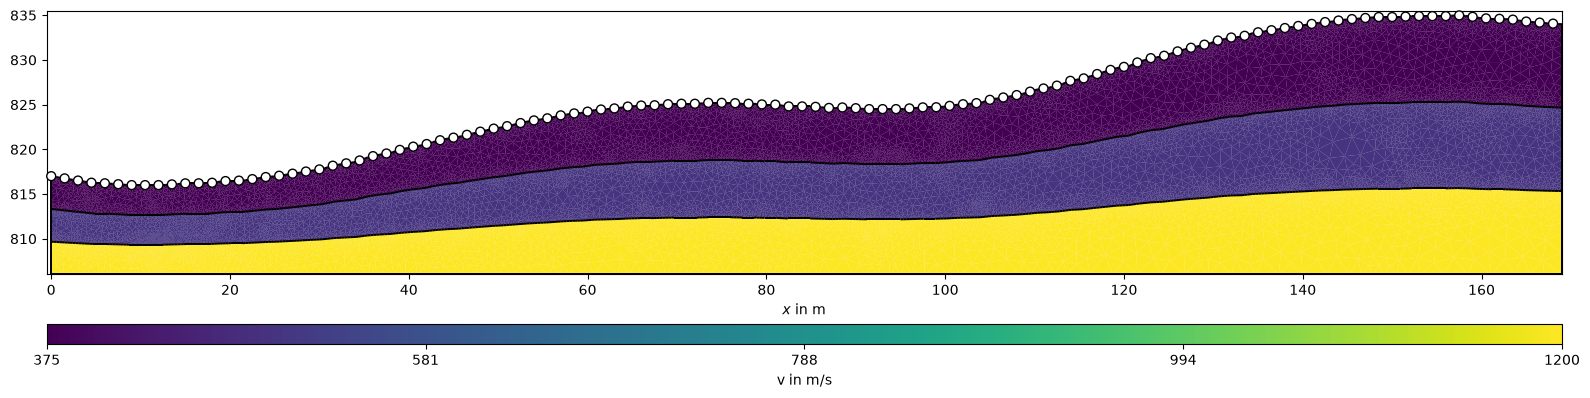

In [7]:
vp = np.array(mesh.cellMarkers(), dtype=float)
vp[vp == 1] = VP_LAYER1
vp[vp == 2] = VP_LAYER2
vp[vp == 3] = VP_LAYER3

fig, ax = plt.subplots(figsize=(16, 6))
ax, _ = pg.show(mesh, vp, colorBar=True, logScale=False, label='v in m/s', ax=ax)
pg.viewer.mpl.drawSensors(ax, scheme.sensors(), diam=1.0,
                          facecolor='white', edgecolor='black')


## 4. Simulasi Traveltime
Memakai parameter noise dari bagian 0.F.

In [8]:
data = tt.simulate(slowness=1.0 / vp, scheme=scheme, mesh=mesh,
                   noiseLevel=NOISE_LEVEL, noiseAbs=NOISE_ABS, seed=SEED, verbose=True)


06/10/26 - 19:32:16 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


min/max t: 0.0037606761969428385 0.19613575610177716


## 5. Visualisasi Data Traveltime

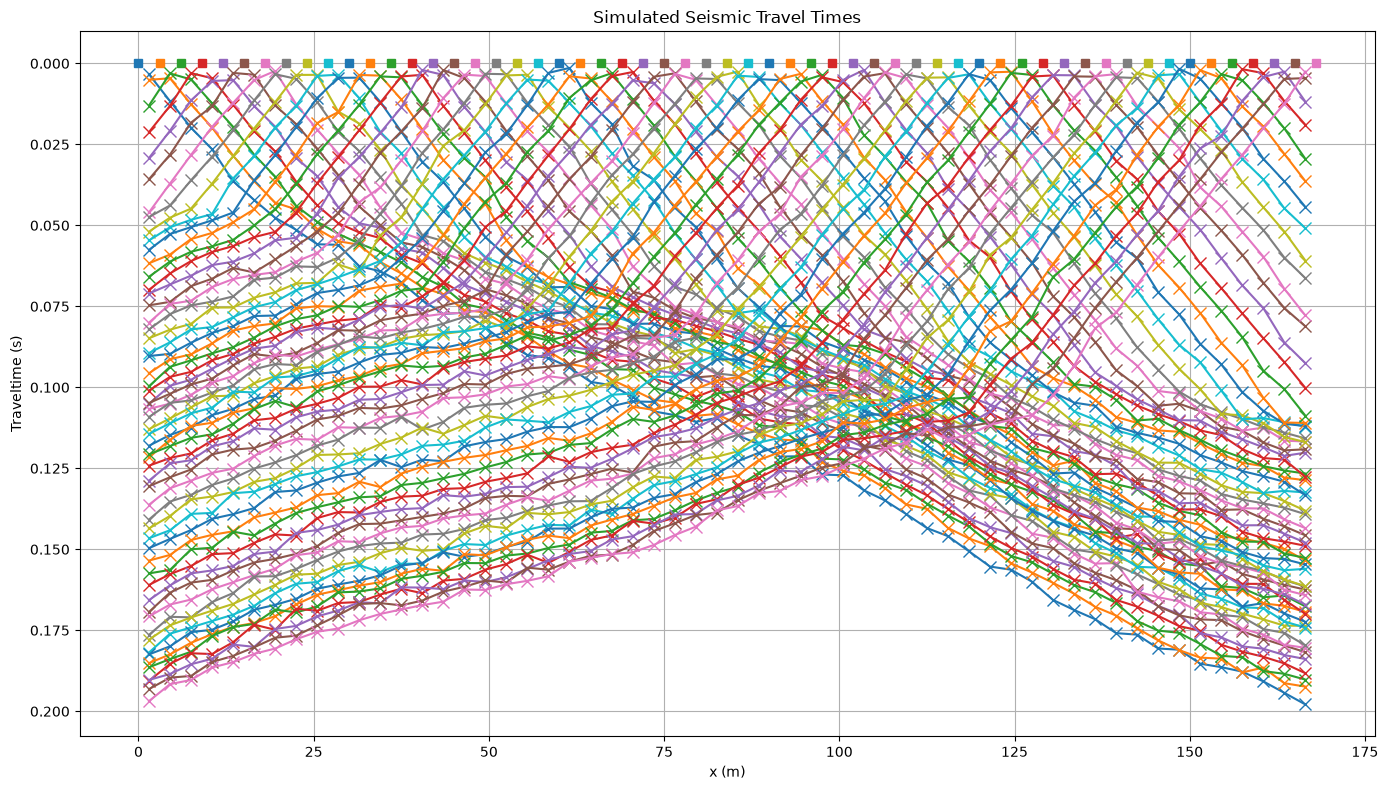

In [9]:
tt.show(data)
fig = plt.gcf()
fig.set_size_inches(14, 8)
plt.title('Simulated Seismic Travel Times')
plt.tight_layout()
plt.show()


## 6. Inversi Traveltime
Memakai parameter inversi dari bagian 0.G.

In [10]:
mgr = tt.TravelTimeManager(data)
vest = mgr.invert(secNodes=SEC_NODES, paraMaxCellSize=PARA_MAX_CELL_SIZE,
                  maxIter=MAX_ITER, verbose=True)
np.testing.assert_array_less(mgr.inv.inv.chi2(), 1.1)


06/10/26 - 19:32:39 - pyGIMLi - INFO - Found 1 regions.
06/10/26 - 19:32:39 - pyGIMLi - INFO - Found 1 regions.
06/10/26 - 19:32:39 - pyGIMLi - INFO - Creating forward mesh from region infos.
06/10/26 - 19:32:39 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
06/10/26 - 19:32:39 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
06/10/26 - 19:32:39 - pyGIMLi - INFO - Created startmodel from forward operator:2649, min/max=0.000200/0.002000
06/10/26 - 19:32:39 - pyGIMLi - INFO - Starting inversion.
06/10/26 - 19:32:39 - pyGIMLi - INFO - fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x0000010D29322750>
06/10/26 - 19:32:39 - pyGIMLi - INFO - Data transformation: Identity transform
06/10/26 - 19:32:39 - pyGIMLi - INFO - Model transformation: Logarithmic transform
06/10/26 - 19:32:39 - pyGIMLi - INFO - min/max (data): 0.0014/0.2
06/10/26 - 19:32:39 - pyGIMLi - INFO - min/max (error): 0.6%/72.19%
06/10/26 - 19:32:39 - 

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
inv.iter 1 ... 

06/10/26 - 19:32:58 - pyGIMLi - INFO - chi² =   11.70 (dPhi = 99.04%) lam: 20.0
06/10/26 - 19:33:11 - pyGIMLi - INFO - chi² =    9.09 (dPhi = 22.24%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 2 ... --------------------------------------------------------------------------------
inv.iter 3 ... 

06/10/26 - 19:33:18 - pyGIMLi - INFO - chi² =    5.56 (dPhi = 38.53%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 13 ... 

06/10/26 - 19:36:17 - pyGIMLi - INFO - chi² =    1.01 (dPhi = 3.08%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 14 ... 

06/10/26 - 19:36:34 - pyGIMLi - INFO - chi² =    0.98 (dPhi = 3.52%) lam: 20.0




################################################################################
#                  Abort criterion reached: chi² <= 1 (0.98)                   #
################################################################################


## 7. Visualisasi Hasil Inversi

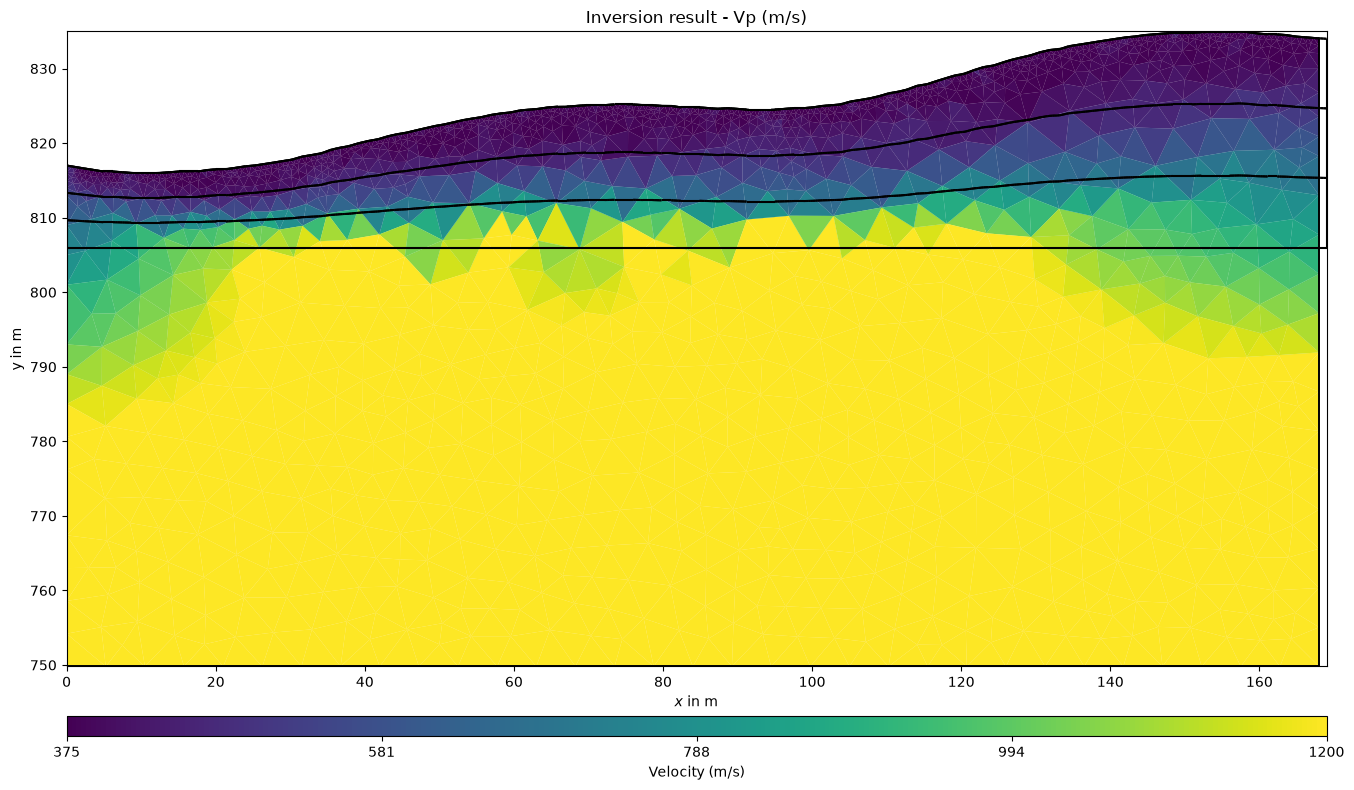

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(16, 8))

ax, cb = mgr.showResult(cMin=min(vp), cMax=max(vp), logScale=False, ax=axes)
ax.set_title("Inversion result - Vp (m/s)")
ax.set_xlabel("x in m")
ax.set_ylabel("y in m")

pg.show(geom, ax=ax, fillRegion=False, regionMarker=False)

plt.tight_layout()
plt.show()


## 8. Fit Data Inversi

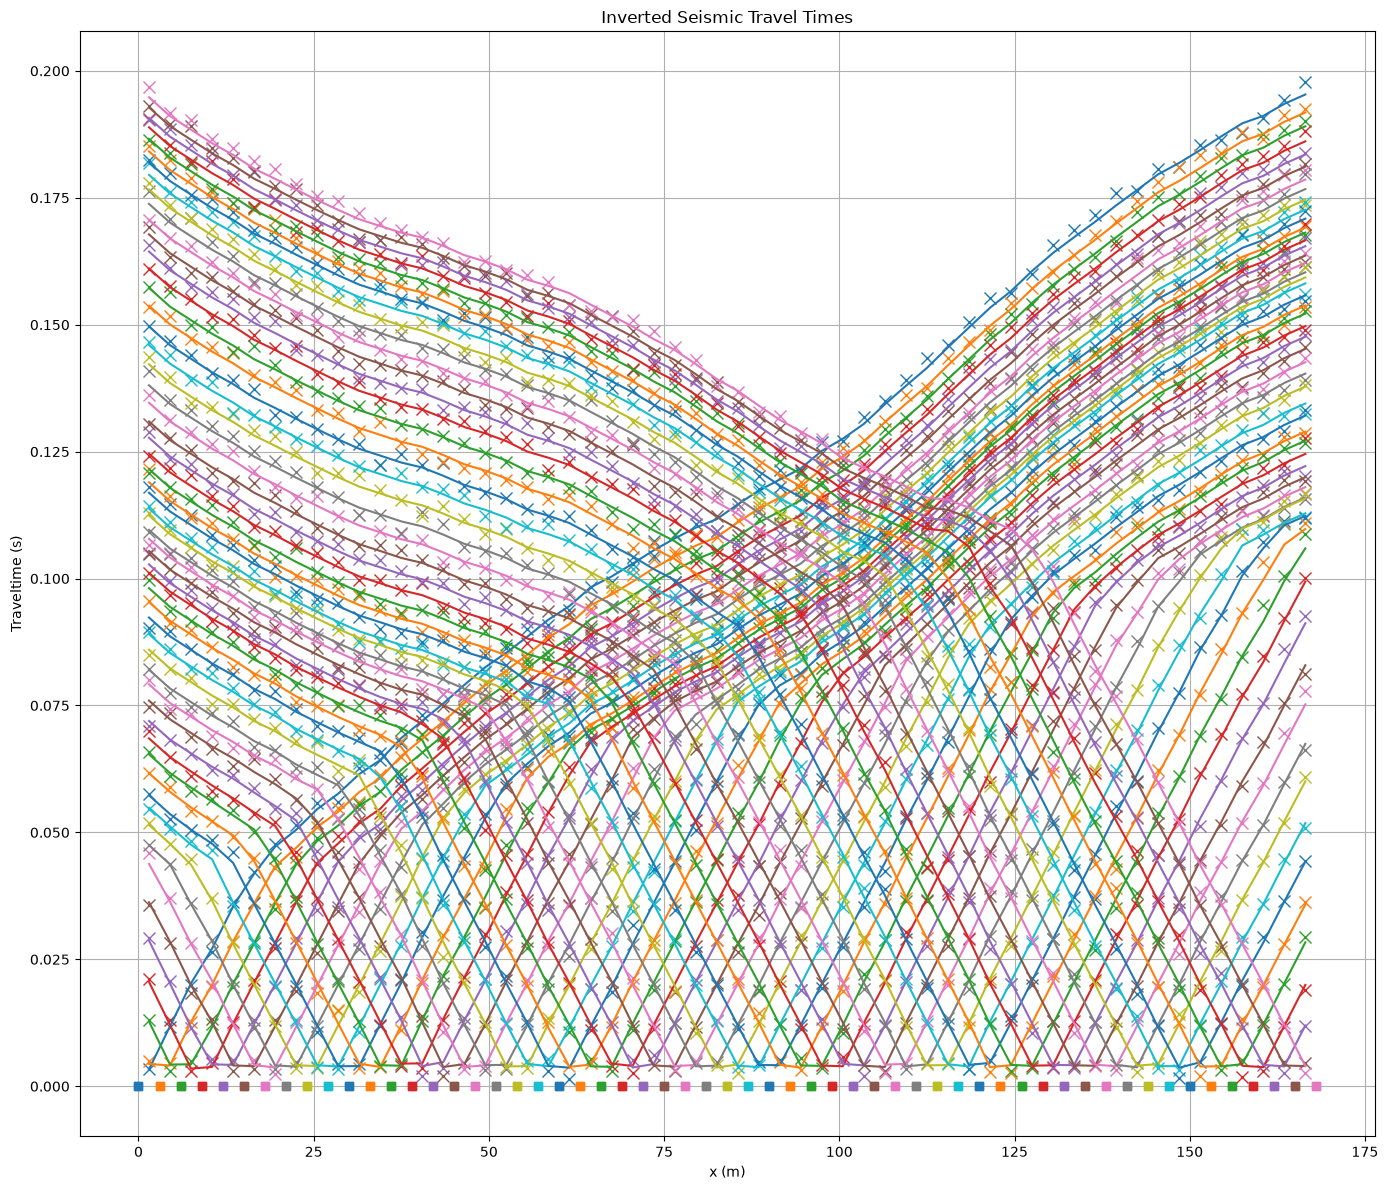

In [12]:
mgr.showFit(firstPicks=True)
fig = plt.gcf()
fig.set_size_inches(14, 12)
plt.title('Inverted Seismic Travel Times')
plt.tight_layout()
plt.show()
